# Mount Drive



In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# import libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Read Image

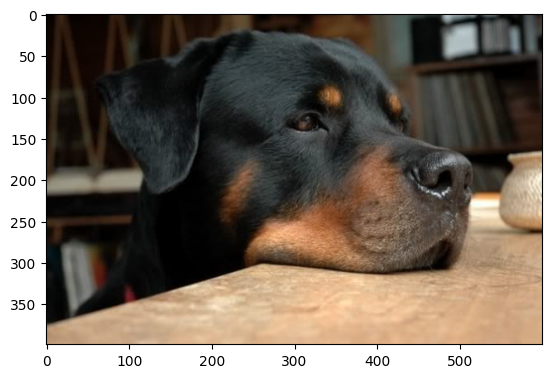

In [40]:
img = mpimg.imread('/content/drive/MyDrive/ML/computational data mining/تمرین چهارم/rgb_dog.jpg')

plt.imshow(img)

In [41]:
print(type(img))

<class 'numpy.ndarray'>


In [42]:
print('shape of image :', img.shape)

shape of image : (399, 600, 3)


# Singular Value Decomposition

### Singular Value Decomposition for grayscale image

Importing the Image to Reduce and setting the plot size

Converting the RGB image to grayscale

By converting an RGB image to grayscale, we can remove the color information from the image and simplify it to a single channel of brightness values. This can make the image easier to process and analyze, particularly if we are only interested in the overall shape or texture of the image.

Here in the below code the np.mean method is used to convert the RGB image to grayscale by taking the mean of the RGB values along the last dimension (-1).

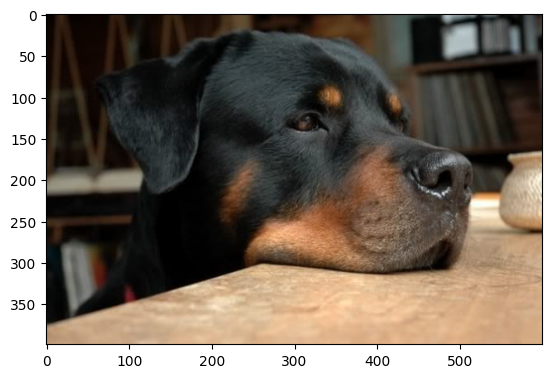

In [43]:
img = mpimg.imread('/content/drive/MyDrive/ML/computational data mining/تمرین چهارم/rgb_dog.jpg')

plt.imshow(img)

In [44]:
X = np.mean(img, -1); #convert RGB to Grayscale
print(X.shape) #to check the original image shape

(399, 600)


Displaying the original image:

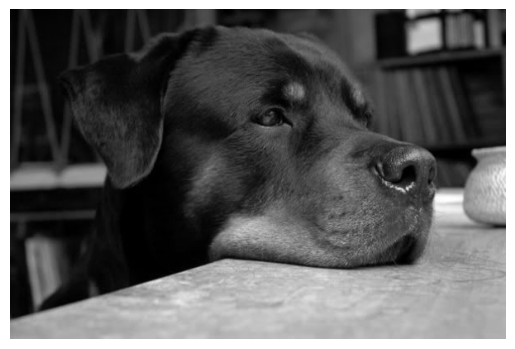

In [45]:
img = plt.imshow(X)
img.set_cmap('gray') #simply just changing the BG
plt.axis('off')
plt.show()

Computing the SVD of the image:

The linalg.svd method from NumPy is used to perform Singular Value Decomposition (SVD) on the grayscale image. The full_matrices parameter is set to False to save memory.

In [46]:
U, S, VT = np.linalg.svd(X, full_matrices = False) #camputuring the singular values and left and right singular vector

Reconstruct the image for different values of r:

Here r is the latent component. For different values of r the image compression is performed. For higher values of r we can see an image which is similar to the original image and the compression ratio will be higer on the contrary for lower values of r the impage get blured which is not that clear to visualize but in this case we will get lower compression ratio.

The compression ratio is calculated as the size of the compressed image divided by the size of the original image. The size of the compressed image is determined by the number of singular values and vectors retained during the compression process. Specifically, the size of the compressed image is proportional to r * (1 + row + col), where r is the number of singular values retained, and row and col are the dimensions of the original image.

As we increase the value of r, we are retaining more singular values and vectors, which means that the size of the compressed image is increasing. However, since we are still representing the image using fewer singular values and vectors than the original image, the size of the compressed image is still smaller than the original image. This results in an increasing compression ratio as we increase the value of r.

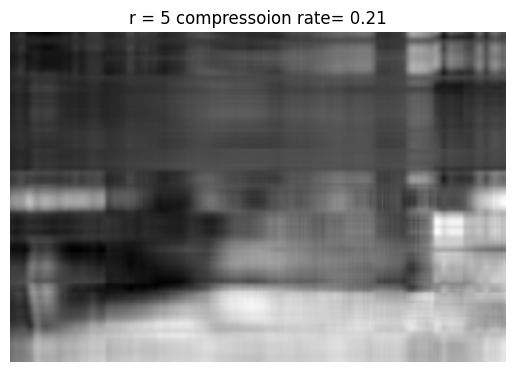

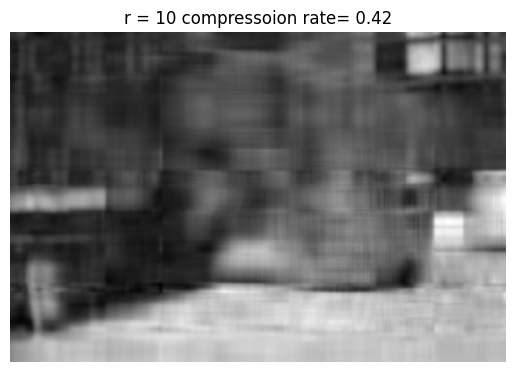

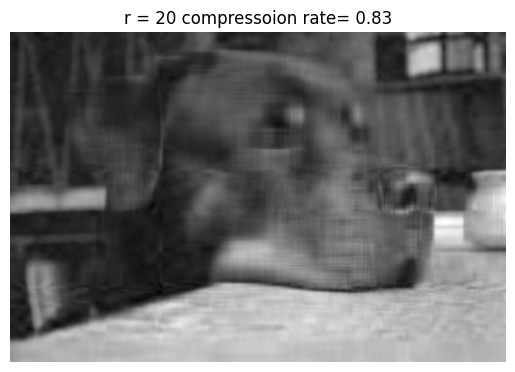

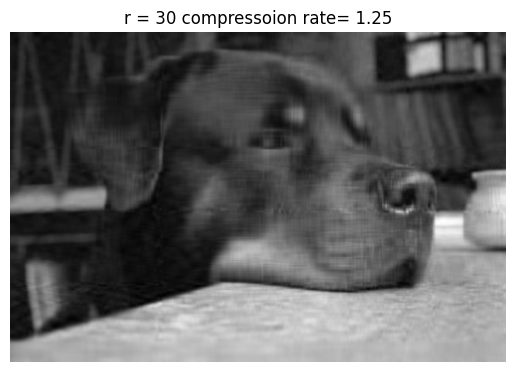

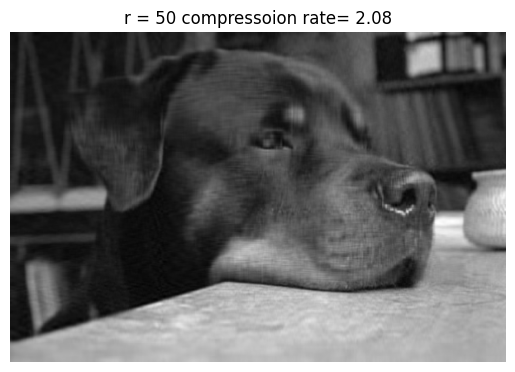

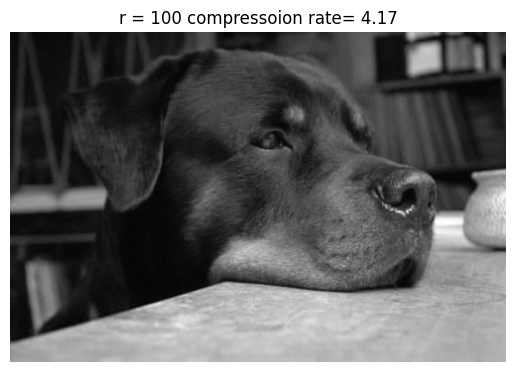

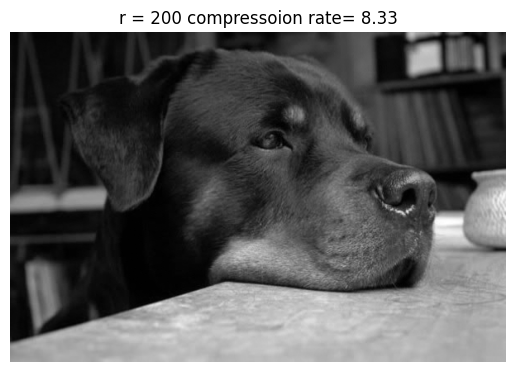

In [47]:
S = np.diag(S)

j = 0
row=4000
col=6000

for r in (5, 10, 20, 30, 50, 100, 200):
    Xapprox = U[:, :r] @ S[0:r, :r] @ VT[:r, :]
    plt.figure(j+1)
    j += 1
    original_size = row*col
    compressedSize = r * (1 + row+col)
    compression_ratio = compressedSize*1.0/ original_size
    img = plt.imshow(Xapprox)
    plt.title('r = {} compressoion rate= {}'.format(r,round(compression_ratio*100,2)))
    img.set_cmap('gray')
    plt.axis('off')
    plt.show()

Singular Vlaues of latent Component:

Form the below plot we can see that initial latent components are having higher singular values which means this can capture high number of variablity in the original dataset.

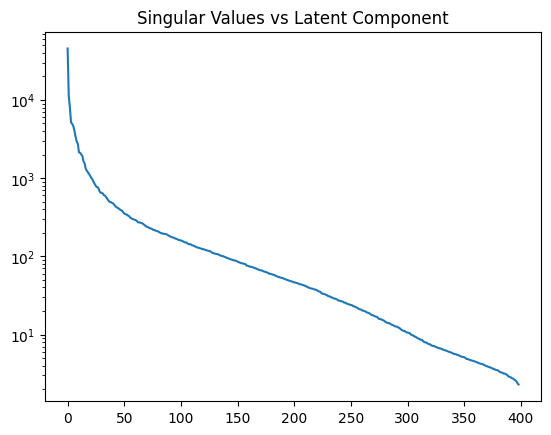

In [48]:
plt.figure(1)
plt.semilogy(np.diag(S))
plt.title('Singular Values vs Latent Component')
plt.show()

### Singular Value Decomposition for rgb image

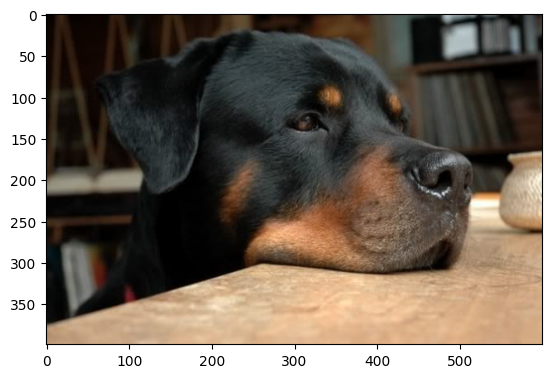

In [49]:
img = mpimg.imread('/content/drive/MyDrive/ML/computational data mining/تمرین چهارم/rgb_dog.jpg')

plt.imshow(img)

In [50]:
img = img.astype(np.float64) / 255.0

In [51]:
#3D image
#   ↓ slice
#3 × 2D matrices
#   ↓
#SVD works on each

R = img[:, :, 0]
G = img[:, :, 1]
B = img[:, :, 2]


In [52]:
U_R, S_R, VT_R = np.linalg.svd(R, full_matrices = False) #camputuring the singular values and left and right singular vector
U_G, S_G, VT_G = np.linalg.svd(G, full_matrices = False) #camputuring the singular values and left and right singular vector
U_B, S_B, VT_B = np.linalg.svd(B, full_matrices = False) #camputuring the singular values and left and right singular vector

In [53]:
print(R.shape)
print(U_R.shape)
print(S_R.shape)
print(VT_R.shape)

(399, 600)
(399, 399)
(399,)
(399, 600)


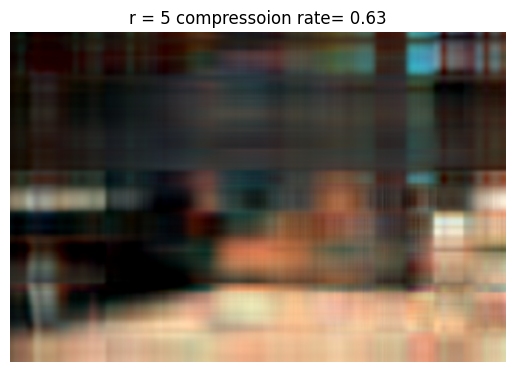

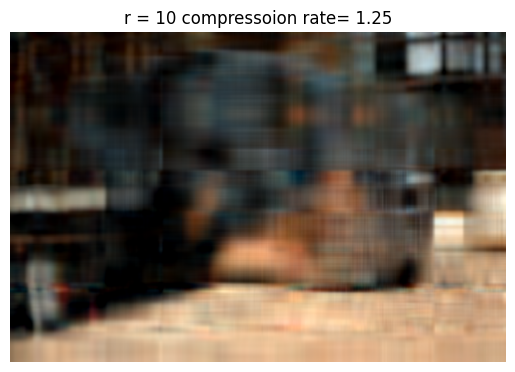

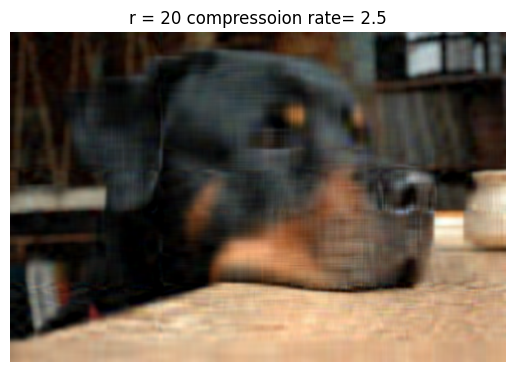

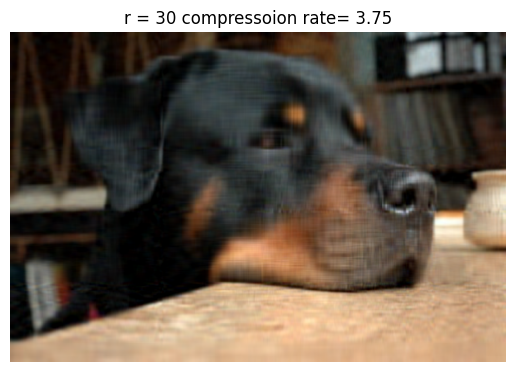

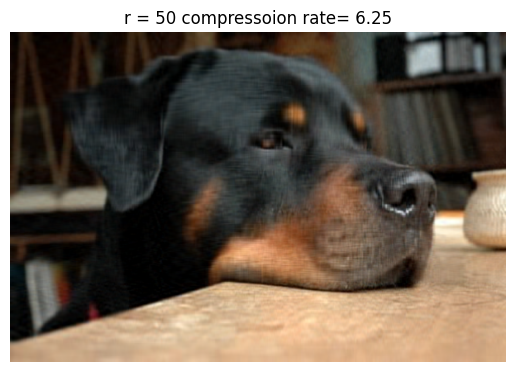

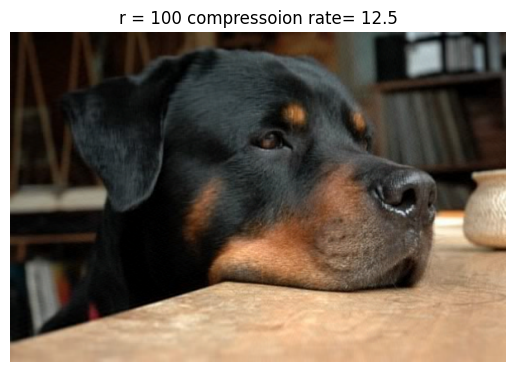

In [54]:
j = 0
row=4000
col=6000

for r in (5, 10, 20, 30, 50, 100):

    R_r = U_R[:, :r] @ np.diag(S_R[:r]) @ VT_R[:r, :]
    G_r = U_G[:, :r] @ np.diag(S_G[:r]) @ VT_G[:r, :]
    B_r = U_B[:, :r] @ np.diag(S_B[:r]) @ VT_B[:r, :]

    img_r = np.stack((R_r, G_r, B_r), axis=2)

    plt.figure(j+1)
    j += 1
    original_size = row*col
    # Multiply by 3 because RGB image has 3 channels (R, G, B)
    # Compression size for RGB image:
    # each channel requires r singular values + U (m×r) + V^T (r×n)
    compressedSize = 3 * r * (1 + row+col)
    compression_ratio = compressedSize*1.0/ original_size
    img = plt.imshow(img_r)
    plt.title('r = {} compressoion rate= {}'.format(r,round(compression_ratio*100,2)))
    #img.set_cmap('gray')
    plt.axis('off')
    plt.show()

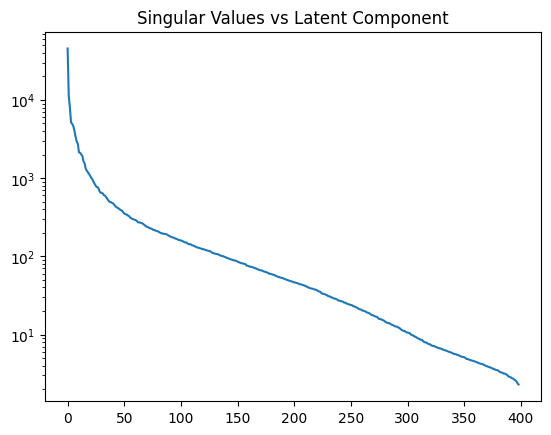

In [55]:
plt.figure(1)
plt.semilogy(np.diag(S))
plt.title('Singular Values vs Latent Component')
plt.show()